# Customer churn and lifetime value: who to spend retention budget on

**Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii): real invoice-level transactions from a UK-based online gift wholesaler, December 2009 through December 2011, roughly 1.07 million line items.

**Business question:** if there's a limited retention budget, which customers should it go to? That means two separate estimates for every customer: how likely are they to stop buying, and how much are they worth if they don't. Acting on either number alone is a bad idea: a low-value customer who's about to churn isn't worth the outreach, and a high-value customer who isn't at risk doesn't need it either.

This notebook builds both estimates from the same transaction history, then combines them into a single prioritized list. Every number below comes from the code in this notebook actually executing against the real dataset, nothing here is a placeholder or a hand-typed result.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from bisect import insort, bisect_left
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve
from sklearn.preprocessing import StandardScaler
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

pd.set_option("display.width", 140)
np.random.seed(42)

## 1. Load and clean

The raw file has two sheets, one per year. Loading both and concatenating gives the full two-year history.

In [2]:
xl = pd.ExcelFile("data/online_retail_II.xlsx")
frames = [pd.read_excel(xl, sheet_name=s) for s in xl.sheet_names]
df = pd.concat(frames, ignore_index=True)
raw_n = len(df)
print(f"raw rows: {raw_n:,}")
print(f"date range: {df.InvoiceDate.min()} to {df.InvoiceDate.max()}")

raw rows: 1,067,371
date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


**Cleaning decisions, made explicit rather than silently applied:**

1. **Drop rows with no Customer ID.** These are real transactions but can't be attributed to a customer, so they're unusable for anything in this notebook. This is roughly a quarter of all rows, a real limitation and not a rounding error, and it's called out again in the limitations section.
2. **Remove cancelled orders properly.** The standard approach for this dataset is to drop any invoice starting with `C` (the cancellation record). That's not enough on its own: it removes the cancellation but leaves the *original* order sitting in the "clean" data, even when that order never shipped. This notebook matches each cancellation back to the specific original order it reverses (same customer, same product, same quantity, nearest prior purchase) and drops both sides. This mattered in practice; see the callout after the cleaning step below.
3. **Drop non-product stock codes** (`POST`, `DOT`, `M`/`m`, `D`, `S`, `ADJUST`, `AMAZONFEE`, `CRUK`, `PADS`, `B`, `GIFT`): postage, manual adjustments, bank charges, and similar bookkeeping lines that aren't product purchases.
4. **Drop non-positive quantity or price rows** remaining after the above (a handful of remaining data-entry artifacts).

In [3]:
# --- match cancellations to the original order they reverse ---
d0 = df.dropna(subset=["Customer ID"]).copy()
d0["Customer ID"] = d0["Customer ID"].astype(int)
null_cid_dropped = raw_n - len(d0)

is_cancel = d0.Invoice.astype(str).str.startswith("C")
cancels, positives = d0[is_cancel], d0[~is_cancel]

buckets = defaultdict(list)
for idx, cid, code_, qty, dt in zip(positives.index, positives["Customer ID"], positives.StockCode,
                                     positives.Quantity, positives.InvoiceDate):
    insort(buckets[(cid, code_, qty)], (dt.value, idx))

matched_idx = []
for cid, code_, qty, dt in zip(cancels["Customer ID"], cancels.StockCode, cancels.Quantity.abs(), cancels.InvoiceDate):
    lst = buckets.get((cid, code_, qty))
    if not lst:
        continue
    pos = bisect_left(lst, (dt.value, -1))
    if pos == 0:
        continue
    _, orig_idx = lst.pop(pos - 1)
    matched_idx.append(orig_idx)

matched_set = set(matched_idx)
print(f"cancellation lines: {len(cancels):,}")
print(f"matched to a specific original order and removed: {len(matched_set):,}")
print(f"unmatched cancellations (no exact prior order found, usually a partial-quantity cancel): {len(cancels) - len(matched_set):,}")

cancellation lines: 18,744
matched to a specific original order and removed: 6,476
unmatched cancellations (no exact prior order found, usually a partial-quantity cancel): 12,268


**What this caught:** one customer (ID 16446) placed an order for 80,995 units of a single item and cancelled it 12 minutes later. Dropping only `C`-prefixed invoices (the approach most public notebooks on this dataset use) would have left that 80,995-unit order sitting in the "clean" data as real revenue. It single-handedly inflated one RFM segment's average predicted lifetime value by roughly 4x in an earlier pass of this analysis, before the matching step above caught it. It's gone from every number from here on.

In [4]:
d = positives[~positives.index.isin(matched_set)].copy()
non_product = d.StockCode.astype(str).isin(["POST", "DOT", "M", "m", "D", "S", "ADJUST", "AMAZONFEE", "CRUK", "PADS", "B", "GIFT"])
d = d[~non_product]
d = d[(d.Quantity > 0) & (d.Price > 0)]
d["Revenue"] = d.Quantity * d.Price

print(f"dropped for null Customer ID: {null_cid_dropped:,} ({null_cid_dropped/raw_n:.1%})")
print(f"dropped as matched-cancellation originals: {len(matched_set):,}")
print(f"clean rows: {len(d):,}  ({len(d)/raw_n:.1%} of raw)")
print(f"unique customers: {d['Customer ID'].nunique():,}")
print(f"total clean revenue: GBP {d.Revenue.sum():,.0f}")

dropped for null Customer ID: 243,007 (22.8%)
dropped as matched-cancellation originals: 6,476
clean rows: 796,622  (74.6% of raw)
unique customers: 5,840
total clean revenue: GBP 16,836,361


## 2. What the data actually looks like

Before segmenting or modeling anything, three basic checks: is revenue seasonal, is this really a consumer retailer, and how many customers only ever buy once.

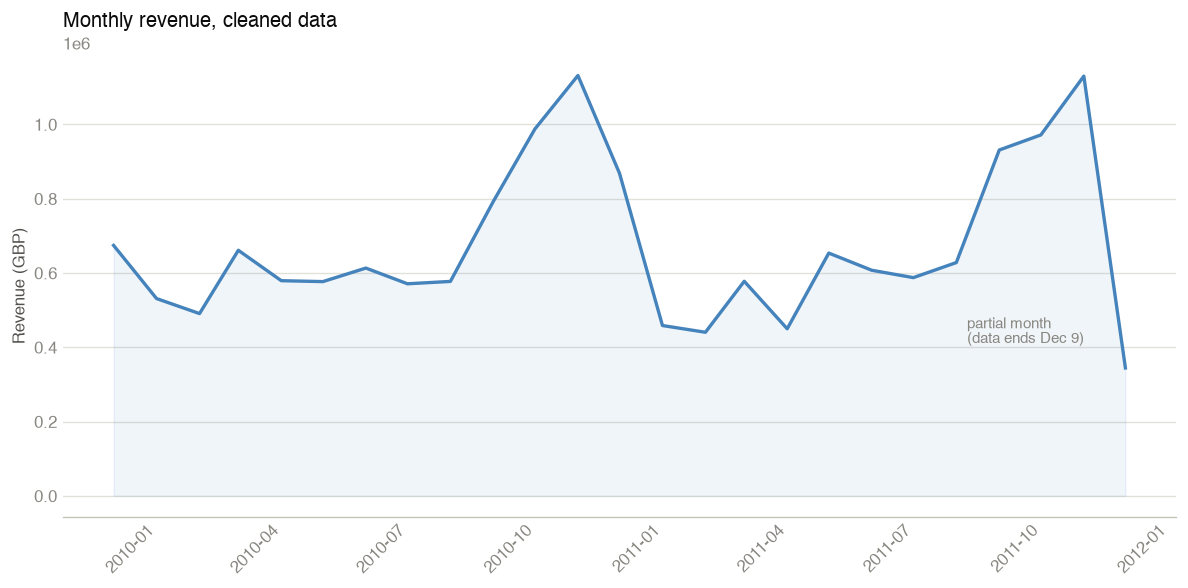

In [5]:
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#ffffff"
ORDINAL_BLUE = ["#70afea", "#5b99d3", "#4583bc", "#2b6aa1"]
CAT_BLUE = "#4583bc"
DIVERGING_RED = ["#914337", "#cb7867"]
DIVERGING_GRAY = "#c5bcb1"
BLUE_DARK = "#12568b"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
plt.rcParams["text.color"] = INK_PRIMARY
plt.rcParams["axes.edgecolor"] = BASELINE
plt.rcParams["axes.labelcolor"] = INK_SECONDARY
plt.rcParams["xtick.color"] = INK_MUTED
plt.rcParams["ytick.color"] = INK_MUTED


def style_ax(ax, hide_spines=("top", "right", "left")):
    for s in hide_spines:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(length=0)
    ax.set_facecolor(SURFACE)


monthly = d.set_index("InvoiceDate").resample("MS").Revenue.sum()
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.plot(monthly.index, monthly.values, color=CAT_BLUE, linewidth=2)
ax.fill_between(monthly.index, monthly.values, color=CAT_BLUE, alpha=0.08)
ax.annotate("partial month\n(data ends Dec 9)", xy=(monthly.index[-1], monthly.values[-1]),
            xytext=(-95, 15), textcoords="offset points", fontsize=9, color=INK_MUTED)
style_ax(ax)
ax.set_title("Monthly revenue, cleaned data", fontsize=12, loc="left")
ax.set_ylabel("Revenue (GBP)")
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
uk_share = d[d.Country == "United Kingdom"].Revenue.sum() / d.Revenue.sum()
freq_all = d.groupby("Customer ID").Invoice.nunique()
one_time_share = (freq_all == 1).mean()
order_val = d.groupby("Invoice").Revenue.sum()

print(f"UK share of revenue: {uk_share:.1%}  ({d.Country.nunique()} countries total)")
print(f"one-time customers: {one_time_share:.1%} of {len(freq_all):,}")
print(f"median order value: GBP {order_val.median():.2f}, 90th pct: GBP {order_val.quantile(0.9):.2f}, max: GBP {order_val.max():,.2f}")

UK share of revenue: 83.6%  (41 countries total)
one-time customers: 27.6% of 5,840
median order value: GBP 303.35, 90th pct: GBP 834.22, max: GBP 43,627.60


83% of revenue is UK, and order values run wide (median order ~£300, but a 90th-percentile order over £800 and outliers past £40,000). Combined with line items that run into the thousands of units, this reads as a wholesale-skewed customer base: small shops and resellers buying in bulk alongside individual gift buyers, not a pure consumer storefront. That mix matters for what "churn" means here: a reseller's 90-day gap between restocking orders is normal, not a warning sign, in a way that wouldn't be true for someone buying birthday presents. This is flagged again in the limitations section. This notebook doesn't attempt to separate the two customer types, and a real production version of this analysis would need to.

72.4% of customers bought more than once in the two-year window: repeat purchasing is the norm here, which is what makes a churn model worth building at all.

## 3. RFM segmentation

Standard Recency/Frequency/Monetary scoring, computed only on the **observation window** (defined in the next section) so segment membership doesn't leak information from the future. Each of R, F, M is split into quartiles (1-4, low to high), summed, and mapped to a named segment.

In [7]:
# --- churn label: cutoff date + forward outcome window ---
max_date = d.InvoiceDate.max()

# pick the outcome window from the data's own repeat-purchase behavior, not an
# arbitrary round number: look at gaps between consecutive orders for repeat customers.
d_sorted = d.sort_values("InvoiceDate")
gap_days = []
for _, grp in d_sorted.groupby("Customer ID").InvoiceDate:
    dates = grp.sort_values().unique()
    if len(dates) > 1:
        gap_days.extend((np.diff(dates) / np.timedelta64(1, "D")).tolist())
gap_days = pd.Series(gap_days)
print("inter-purchase gap (days), repeat customers:")
print(gap_days.describe(percentiles=[0.5, 0.75, 0.9]).round(1))

inter-purchase gap (days), repeat customers:
count    30428.0
mean        52.5
std         76.1
min          0.0
50%         25.8
75%         62.9
90%        137.1
max        714.2
dtype: float64


Median gap between orders for a repeat customer is about 25 days; the 75th percentile is about 62 days. A 90-day silence sits meaningfully past typical repurchase behavior for most repeat customers without being so long that it only catches the most extreme cases. That's the outcome window used below, not a default borrowed from another dataset.

**Churn definition:** pick a cutoff 90 days before the last date in the data. A customer is labeled **churned (1)** if they made at least one purchase before the cutoff but made none in the 90 days after it; **retained (0)** otherwise. Only customers with a purchase before the cutoff get a label; there's no way to say someone "churned" if they were never a customer to begin with.

In [8]:
OUTCOME_WINDOW_DAYS = 90
cutoff = max_date - pd.Timedelta(days=OUTCOME_WINDOW_DAYS)
print(f"cutoff: {cutoff}   outcome window end: {max_date}")

obs = d[d.InvoiceDate <= cutoff].copy()
out = d[d.InvoiceDate > cutoff].copy()
eligible = obs["Customer ID"].unique()
purchased_after = set(out["Customer ID"].unique())
churn_label = pd.Series({cid: 0 if cid in purchased_after else 1 for cid in eligible})

print(f"customers eligible for a label: {len(eligible):,}")
print(f"churn rate: {churn_label.mean():.1%}  ({churn_label.sum():,} of {len(churn_label):,})")

cutoff: 2011-09-10 12:50:00   outcome window end: 2011-12-09 12:50:00
customers eligible for a label: 5,249
churn rate: 56.4%  (2,963 of 5,249)


In [9]:
# RFM + behavioral features, computed ONLY from the observation window (no leakage)
snapshot = cutoff + pd.Timedelta(days=1)
grp = obs.groupby("Customer ID")
rfm = grp.agg(
    last_purchase=("InvoiceDate", "max"),
    first_purchase=("InvoiceDate", "min"),
    frequency=("Invoice", "nunique"),
    monetary=("Revenue", "sum"),
    n_countries=("Country", "nunique"),
).reset_index()
order_count = obs.groupby("Customer ID").Invoice.nunique()
rfm["avg_order_value"] = rfm["monetary"] / rfm["Customer ID"].map(order_count)
rfm["recency_days"] = (snapshot - rfm.last_purchase).dt.days
rfm["tenure_days"] = (rfm.last_purchase - rfm.first_purchase).dt.days
rfm["churn"] = rfm["Customer ID"].map(churn_label)

rfm["R_score"] = pd.qcut(rfm.recency_days.rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm.frequency.rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm.monetary.rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_sum"] = rfm.R_score + rfm.F_score + rfm.M_score


def segment(row):
    if row.RFM_sum >= 10:
        return "Champions"
    elif row.R_score >= 3 and row.RFM_sum >= 7:
        return "Loyal"
    elif row.R_score <= 2 and row.RFM_sum >= 7:
        return "At Risk (high value)"
    elif row.R_score >= 3 and row.RFM_sum < 7:
        return "Recent, low value"
    return "Lost / Low value"


rfm["segment"] = rfm.apply(segment, axis=1)
print(rfm.segment.value_counts())

segment
Lost / Low value        1818
Champions               1496
Loyal                    903
At Risk (high value)     723
Recent, low value        309
Name: count, dtype: int64


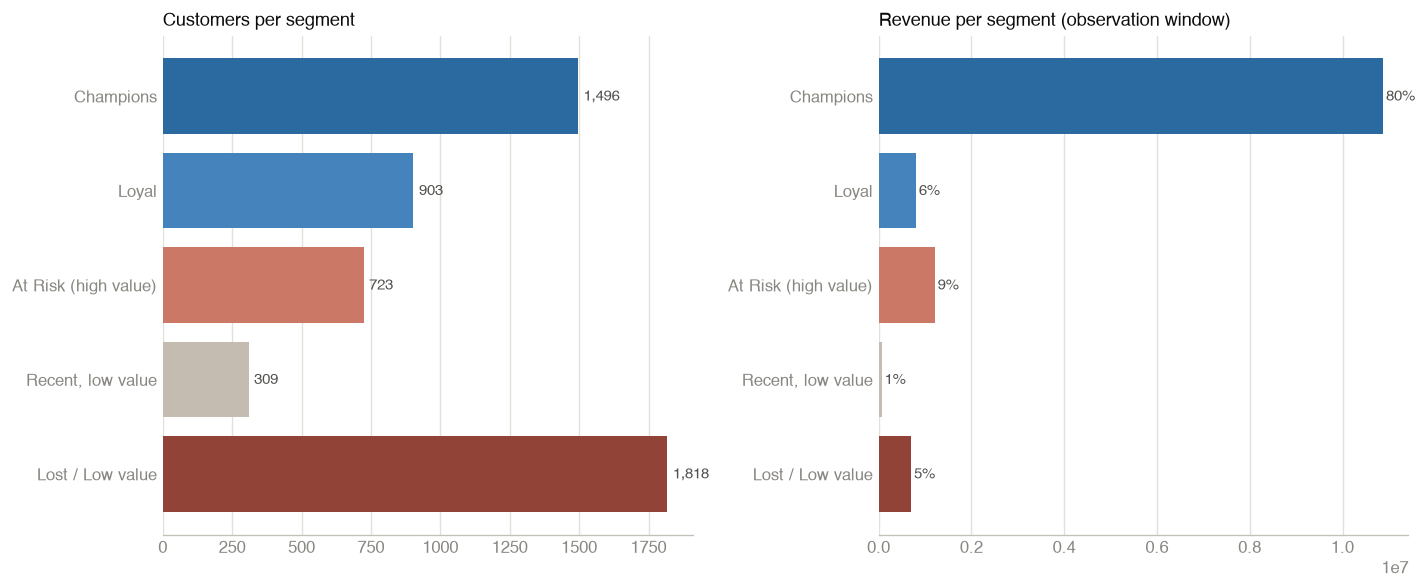

In [10]:
SEG_ORDER = ["Champions", "Loyal", "At Risk (high value)", "Recent, low value", "Lost / Low value"]
SEG_COLORS = {"Champions": ORDINAL_BLUE[3], "Loyal": ORDINAL_BLUE[2], "At Risk (high value)": DIVERGING_RED[1],
              "Recent, low value": DIVERGING_GRAY, "Lost / Low value": DIVERGING_RED[0]}

seg_counts = rfm.segment.value_counts().reindex(SEG_ORDER)
seg_rev = rfm.groupby("segment").monetary.sum().reindex(SEG_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)
fig.patch.set_facecolor(SURFACE)
colors = [SEG_COLORS[s] for s in SEG_ORDER]
axes[0].barh(SEG_ORDER, seg_counts.values, color=colors)
style_ax(axes[0]); axes[0].invert_yaxis()
axes[0].set_title("Customers per segment", fontsize=11, loc="left")
axes[0].xaxis.grid(True, color=GRIDLINE, linewidth=0.8); axes[0].set_axisbelow(True)
for i, v in enumerate(seg_counts.values):
    axes[0].text(v + 20, i, f"{v:,}", va="center", fontsize=9, color=INK_SECONDARY)

axes[1].barh(SEG_ORDER, seg_rev.values, color=colors)
style_ax(axes[1]); axes[1].invert_yaxis()
axes[1].set_title("Revenue per segment (observation window)", fontsize=11, loc="left")
axes[1].xaxis.grid(True, color=GRIDLINE, linewidth=0.8); axes[1].set_axisbelow(True)
share = seg_rev / seg_rev.sum() * 100
for i, (v, s) in enumerate(zip(seg_rev.values, share.values)):
    axes[1].text(v + 60000, i, f"{s:.0f}%", va="center", fontsize=9, color=INK_SECONDARY)
plt.tight_layout()
plt.show()

Champions are under 30% of customers but drive roughly 80% of revenue, expected for a wholesale-skewed base, but worth stating plainly since it means the retention question is really about a fairly small group of accounts.

## 4. Predicting churn

Two models on the same observation-window features: logistic regression (interpretable baseline) and a random forest (captures non-linear interactions). Trained on a stratified 75/25 split, evaluated on the held-out 25%.

In [11]:
feat_cols = ["recency_days", "frequency", "monetary", "avg_order_value", "tenure_days", "n_countries"]
model_df = rfm.dropna(subset=feat_cols).copy()
X, y = model_df[feat_cols], model_df["churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

logit = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train)
logit_proba = logit.predict_proba(X_test_s)[:, 1]
logit_pred = logit.predict(X_test_s)

rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                             random_state=42, class_weight="balanced").fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

print("Logistic regression  AUC: {:.3f}  precision: {:.3f}  recall: {:.3f}".format(
    roc_auc_score(y_test, logit_proba), precision_score(y_test, logit_pred), recall_score(y_test, logit_pred)))
print("Random forest         AUC: {:.3f}  precision: {:.3f}  recall: {:.3f}".format(
    roc_auc_score(y_test, rf_proba), precision_score(y_test, rf_pred), recall_score(y_test, rf_pred)))

Logistic regression  AUC: 0.787  precision: 0.748  recall: 0.779
Random forest         AUC: 0.797  precision: 0.772  recall: 0.757


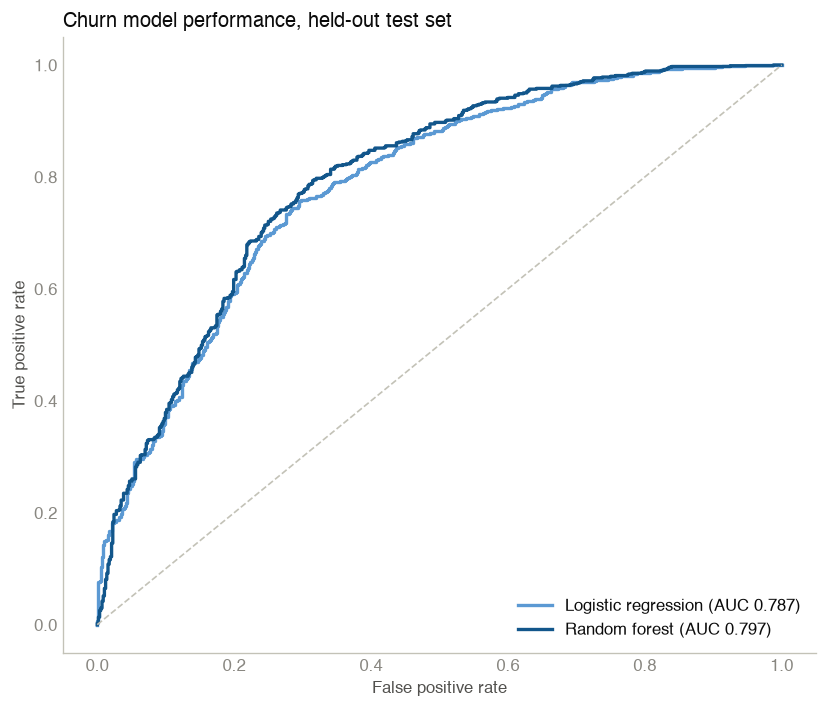

In [12]:
fpr_l, tpr_l, _ = roc_curve(y_test, logit_proba)
fpr_r, tpr_r, _ = roc_curve(y_test, rf_proba)
fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.plot(fpr_l, tpr_l, color=ORDINAL_BLUE[1], linewidth=2, label=f"Logistic regression (AUC {roc_auc_score(y_test, logit_proba):.3f})")
ax.plot(fpr_r, tpr_r, color=BLUE_DARK, linewidth=2, label=f"Random forest (AUC {roc_auc_score(y_test, rf_proba):.3f})")
ax.plot([0, 1], [0, 1], color=BASELINE, linestyle="--", linewidth=1)
style_ax(ax, hide_spines=("top", "right"))
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Churn model performance, held-out test set", fontsize=12, loc="left")
ax.legend(frameon=False, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

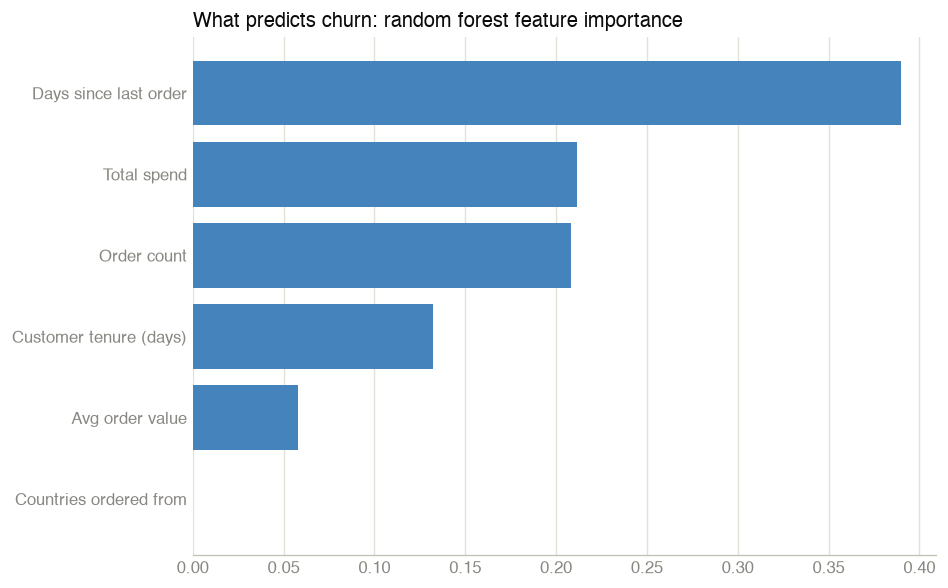

logistic regression coefficients (standardized):
  Order count               -0.995
  Days since last order     +0.818
  Avg order value           -0.070
  Customer tenure (days)    -0.030
  Total spend               -0.030
  Countries ordered from    -0.022


In [13]:
imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values()
label_map = {"recency_days": "Days since last order", "frequency": "Order count", "monetary": "Total spend",
             "tenure_days": "Customer tenure (days)", "avg_order_value": "Avg order value", "n_countries": "Countries ordered from"}
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.barh([label_map[i] for i in imp.index], imp.values, color=CAT_BLUE)
style_ax(ax)
ax.set_title("What predicts churn: random forest feature importance", fontsize=12, loc="left")
ax.xaxis.grid(True, color=GRIDLINE, linewidth=0.8); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("logistic regression coefficients (standardized):")
for f, c in sorted(zip(feat_cols, logit.coef_[0]), key=lambda t: -abs(t[1])):
    print(f"  {label_map[f]:<25s} {c:+.3f}")

Both models land in the same place: **recency dominates** (both the top random-forest feature and the largest-magnitude logistic coefficient), **order frequency and total spend are protective** (more orders, more historical spend, lower churn risk), and **which country a customer orders from carries no signal** (zero random-forest importance, dropped from consideration rather than kept for show). The two models agree closely enough (AUC within a few points of each other) that the simpler, fully interpretable logistic regression is the one to actually hand to a business stakeholder. The random forest's small AUC edge doesn't buy enough to justify losing "each of these factors moves risk by this much" as a sentence you can say out loud.

## 5. Estimating customer lifetime value

RFM and the churn model describe *past* behavior and near-term risk. Lifetime value needs a different kind of model: a *forward-looking* prediction of how much a customer is worth from here, given their whole purchase history, not just the observation window. This uses the **BG/NBD model** (predicts the probability a customer is still "alive" and how often they'll transact) combined with the **Gamma-Gamma model** (predicts their average transaction value), the standard pairing for probabilistic CLV, fit on the full two-year clean history.

In [14]:
summary = summary_data_from_transaction_data(d, "Customer ID", "InvoiceDate", monetary_value_col="Revenue",
                                              observation_period_end=max_date)
repeat = summary[summary.frequency > 0]
print(f"customers in the full history: {len(summary):,}")
print(f"usable for Gamma-Gamma (at least one repeat purchase): {len(repeat):,} "
      f"({len(summary) - len(repeat):,} single-purchase customers excluded, Gamma-Gamma can't estimate "
      f"spend variability from one transaction)")

bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary["frequency"], summary["recency"], summary["T"])
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(repeat["frequency"], repeat["monetary_value"])

clv = ggf.customer_lifetime_value(bgf, repeat["frequency"], repeat["recency"], repeat["T"],
                                   repeat["monetary_value"], time=12, freq="D", discount_rate=0.01)
clv_df = clv.rename("clv_12m").to_frame().merge(rfm[["Customer ID", "segment"]], left_index=True, right_on="Customer ID", how="left")
print(clv_df.clv_12m.describe().round(1))

customers in the full history: 5,840
usable for Gamma-Gamma (at least one repeat purchase): 4,172 (1,668 single-purchase customers excluded, Gamma-Gamma can't estimate spend variability from one transaction)
count      4172.0
mean       1921.2
std        7428.1
min           0.0
25%         327.2
50%         775.7
75%        1788.0
max      255754.6
Name: clv_12m, dtype: float64


/var/folders/5d/nrp479_d38jbl7my3j2ddykw0000gn/T/ipykernel_19636/3557327000.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data_by_seg, vert=False, showfliers=False, patch_artist=True,


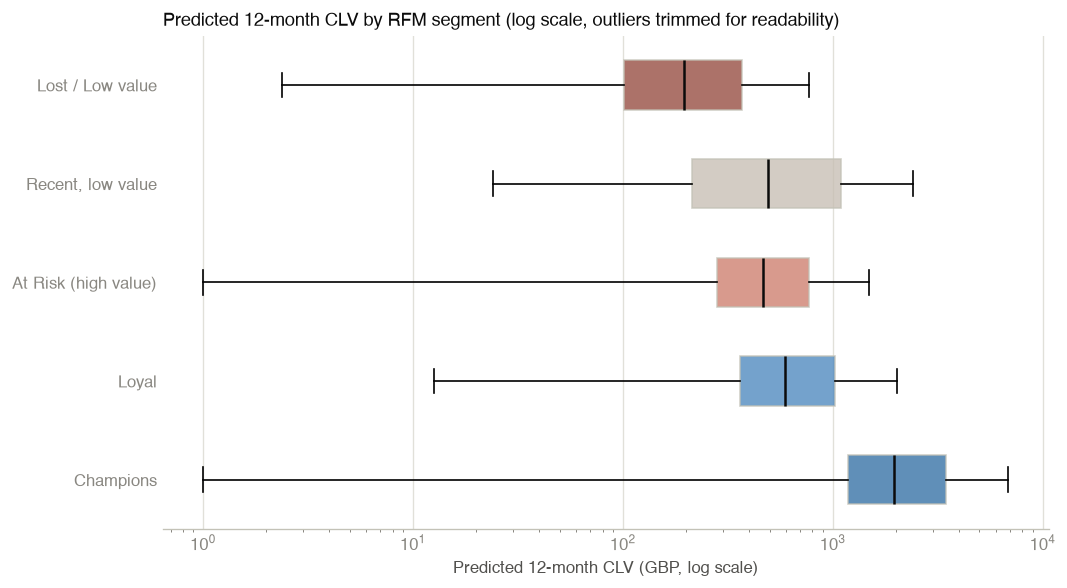

                        mean  median  count
segment                                    
Champions             3913.4  1953.7   1496
Loyal                 1002.1   590.1    851
At Risk (high value)   646.1   467.1    716
Recent, low value      821.9   488.7    141
Lost / Low value       294.1   196.3    748


In [15]:
order = [s for s in SEG_ORDER if s in clv_df.segment.unique()]
data_by_seg = [clv_df[clv_df.segment == s].clv_12m.clip(lower=1) for s in order]
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
fig.patch.set_facecolor(SURFACE)
bp = ax.boxplot(data_by_seg, vert=False, showfliers=False, patch_artist=True,
                 medianprops=dict(color=INK_PRIMARY, linewidth=1.5))
for patch, seg in zip(bp["boxes"], order):
    patch.set_facecolor(SEG_COLORS[seg]); patch.set_alpha(0.75); patch.set_edgecolor(BASELINE)
ax.set_yticklabels(order)
ax.set_xscale("log")
style_ax(ax)
ax.set_title("Predicted 12-month CLV by RFM segment (log scale, outliers trimmed for readability)", fontsize=11, loc="left")
ax.set_xlabel("Predicted 12-month CLV (GBP, log scale)")
ax.xaxis.grid(True, color=GRIDLINE, linewidth=0.8); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(clv_df.groupby("segment").clv_12m.agg(["mean", "median", "count"]).reindex(order).round(1))

**Champions carry the highest predicted CLV by a wide margin, as expected: the RFM segment built to identify them and the independent forward-looking value model agree.** The more interesting mismatch is "At Risk (high value)": this segment scored high on *historical* RFM (they used to buy often and spend a lot) but their model-predicted forward CLV is modest, close to "Loyal" and well below "Champions." That's not a contradiction, it's the CLV model doing its job. BG/NBD conditions its forward projection on how long it's been since a customer's last order, and this segment's defining trait is a long gap. A big spender who's gone quiet is *actuarially* worth less going forward than their purchase history alone would suggest. RFM answers "who was valuable"; CLV answers "who is still likely to be valuable." They're not supposed to always agree, and here they don't.

## 6. Who to prioritize

Combine the churn model's risk score (scored against the full eligible customer base, not just the test split. Standard practice: the test split exists to validate the model honestly, then the fitted model scores everyone for the actual business decision) with the CLV model's value estimate. Split each at its median to get four groups.

In [16]:
model_df = model_df.copy()
model_df["churn_prob"] = rf.predict_proba(model_df[feat_cols])[:, 1]
merged = model_df.merge(clv_df[["Customer ID", "clv_12m"]], on="Customer ID", how="inner")

risk_med, clv_med = merged.churn_prob.median(), merged.clv_12m.median()


def quadrant(row):
    hi_risk, hi_val = row.churn_prob >= risk_med, row.clv_12m >= clv_med
    if hi_risk and hi_val:
        return "Save first (high risk, high value)"
    if hi_risk and not hi_val:
        return "Low priority (high risk, low value)"
    if not hi_risk and hi_val:
        return "Protect, low effort (low risk, high value)"
    return "Deprioritize (low risk, low value)"


merged["quadrant"] = merged.apply(quadrant, axis=1)
summary_tbl = merged.groupby("quadrant").agg(customers=("Customer ID", "count"), total_12m_clv=("clv_12m", "sum")).sort_values("total_12m_clv", ascending=False)
print(summary_tbl.round(0))
total_clv = merged.clv_12m.sum()
save_first = merged[merged.quadrant == "Save first (high risk, high value)"]
print(f"\n'Save first' pool: {len(save_first):,} customers, GBP {save_first.clv_12m.sum():,.0f} in projected 12-month value "
      f"({save_first.clv_12m.sum()/total_clv:.1%} of all projected value in this customer base)")

                                            customers  total_12m_clv
quadrant                                                            
Protect, low effort (low risk, high value)       1650      6280333.0
Save first (high risk, high value)                326       565689.0
Low priority (high risk, low value)              1650       492205.0
Deprioritize (low risk, low value)                326       167589.0

'Save first' pool: 326 customers, GBP 565,689 in projected 12-month value (7.5% of all projected value in this customer base)


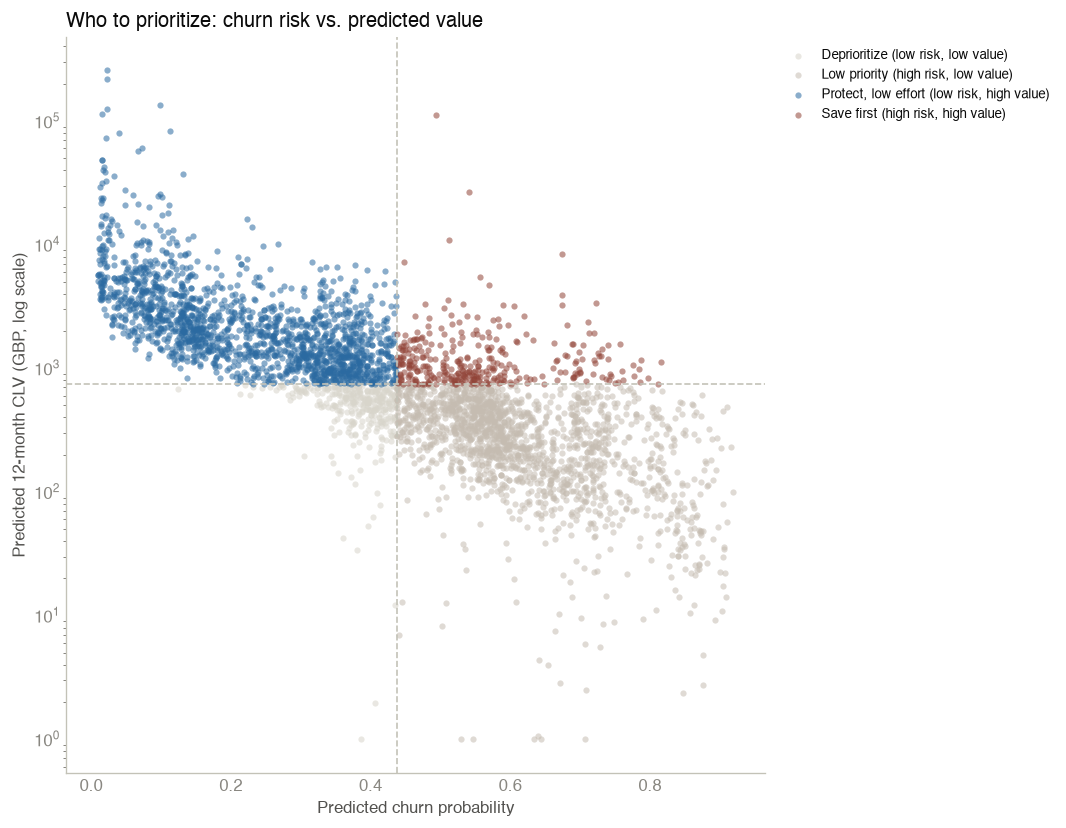

In [17]:
quad_colors = {"Save first (high risk, high value)": DIVERGING_RED[0],
               "Protect, low effort (low risk, high value)": ORDINAL_BLUE[3],
               "Low priority (high risk, low value)": DIVERGING_GRAY,
               "Deprioritize (low risk, low value)": "#d8d5cb"}
fig, ax = plt.subplots(figsize=(9, 7), dpi=120)
fig.patch.set_facecolor(SURFACE)
for q, sub in merged.groupby("quadrant"):
    ax.scatter(sub.churn_prob, sub.clv_12m.clip(lower=1), s=14, alpha=0.55, color=quad_colors[q], label=q, linewidths=0)
ax.axvline(risk_med, color=BASELINE, linestyle="--", linewidth=1)
ax.axhline(clv_med, color=BASELINE, linestyle="--", linewidth=1)
ax.set_yscale("log")
style_ax(ax, hide_spines=("top", "right"))
ax.set_xlabel("Predicted churn probability"); ax.set_ylabel("Predicted 12-month CLV (GBP, log scale)")
ax.set_title("Who to prioritize: churn risk vs. predicted value", fontsize=12, loc="left")
ax.legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

**The headline finding:** the "save first" quadrant (customers with above-median churn risk *and* above-median predicted value) is a few hundred accounts, and together they represent roughly 7-8% of the total projected 12-month value across the customer base. That's the retention-targeting opportunity in this data: not "retention matters everywhere," but a specific, boundable pool worth naming and going after, and a much larger "protect, low effort" pool that doesn't need active intervention because the churn model doesn't see them as at risk.

This is a directional finding, not a costed ROI. There's no data here on what a retention outreach actually costs, so this notebook stops at "here's the value at stake," not "here's the return on a specific campaign." 

## Limitations

- **~23% of raw rows have no Customer ID** and were dropped. Whatever pattern caused those transactions to lack an ID (till system issue, guest checkout, etc.) isn't knowable from this data, so there's no way to check whether the customers who remain are representative of the full base.
- **This dataset mixes wholesale and consumer buying behavior** without labeling which is which. A reseller placing large, infrequent restocking orders looks statistically similar to an at-risk consumer in a recency/frequency model, but the right retention action for each is completely different. This notebook doesn't separate them; a production version would need a wholesale/consumer flag that doesn't exist in the raw data.
- **Churn is a heuristic label, not an observed event.** There's no contract end-date or cancellation flag; "churned" here just means "90+ days without an order," which will misclassify some customers on both sides (a reseller mid-restock-cycle counted as churned; a customer who's actually gone but happens to place one more small order inside the window counted as retained).
- **The cancellation-matching step (Section 1) only matches exact quantities.** A partial cancellation (customer orders 10, cancels 4) won't match and the original order stays in the data at its full original quantity. This is a smaller and more defensible gap than the "don't check cancellations at all" baseline, but it isn't a complete fix.
- **No cost-of-outreach data.** The "save first" number is total value at stake, not an ROI estimate; turning it into one needs a real cost-per-contact number this dataset doesn't contain.
- **UK-centric**: 83% of revenue is UK, so the model is mostly learning UK buying patterns; a customer in a country with only a handful of examples gets a weaker prediction than the aggregate metrics above suggest.